Continuing from makemore 2

* Removing inefficiency in the loop
* Practicing tensor manipulation
* "Broadcasting" https://docs.pytorch.org/docs/2.13/notes/broadcasting.html#general-semantics
    * In my words, if different dimension matrices are going through binary operation like /, * e.g., pytorch smaller vector will become a bigger vector (or matrix) so that the operation can happen. Correct or not, depends on the goal. So this is very important to check work.
    * Keepdims
* likelihood
* Log likelihood
* negative log likelihood
* Model smoothening
* Summary, makemore-4 will have neural network implementation

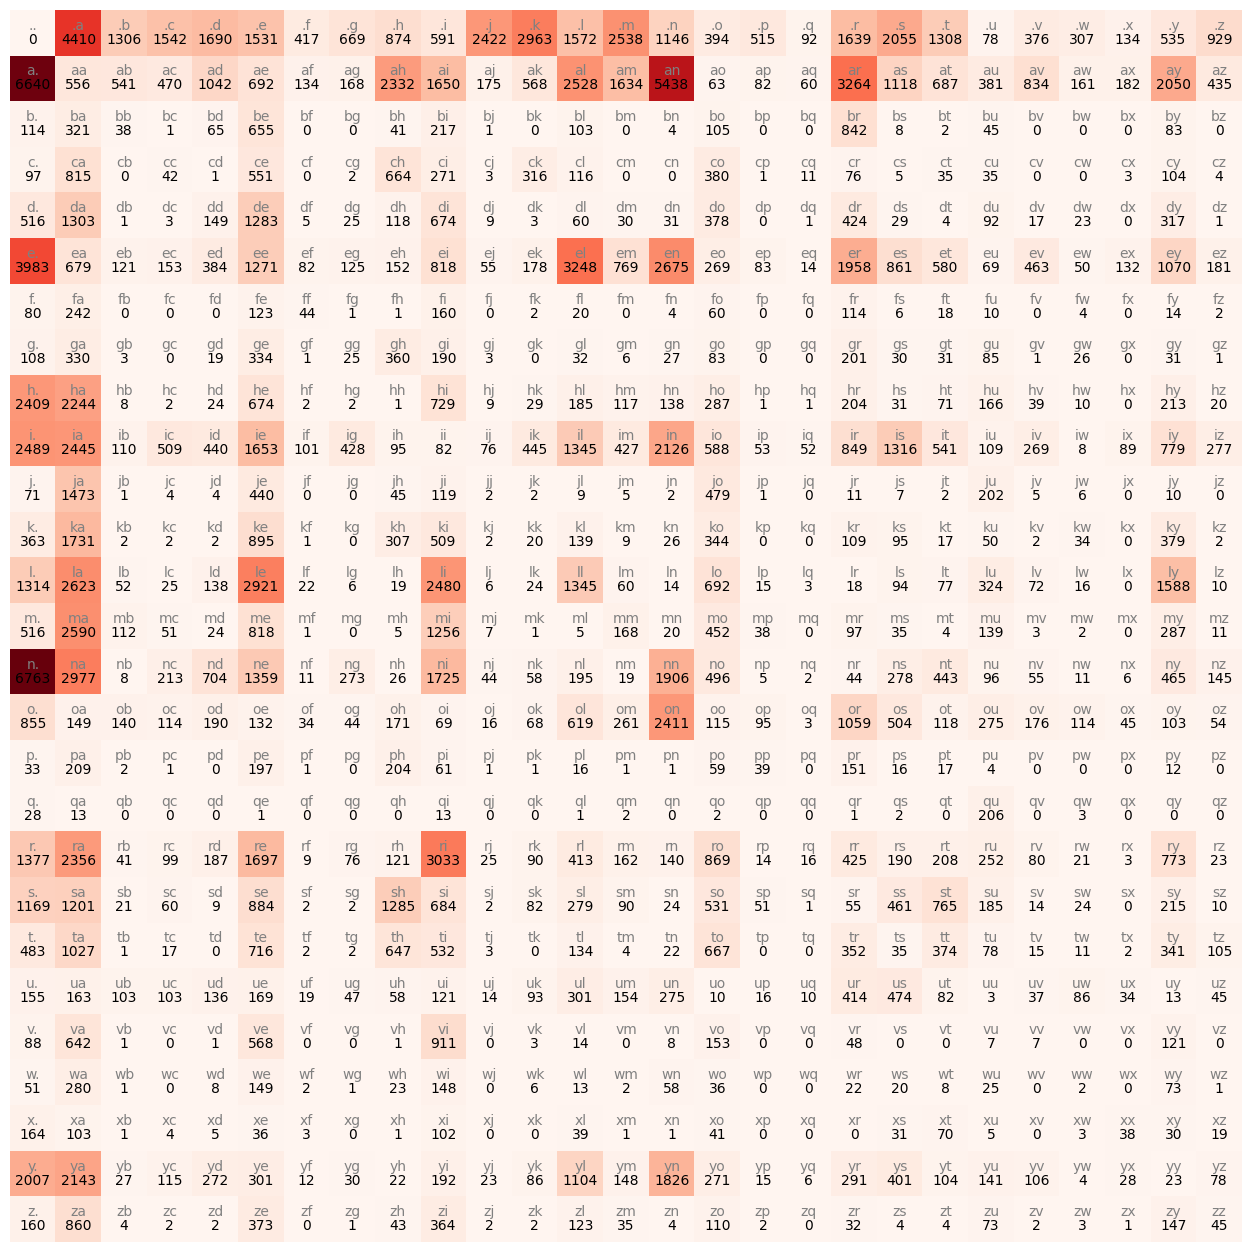

In [24]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline

# Read names.txt
words = open('names.txt', 'r').read().splitlines()

# we will need 26 * 26 for all alphabets + 1 for start char
# so 27 * 27
N = torch.zeros((27, 27), dtype = torch.int32)

# a - z
chars = sorted(list(set(''.join(words))))
stoi = {s:i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0

# N will have bigram counter
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        index1 = stoi[ch1]
        index2 = stoi[ch2]
        N[index1, index2] += 1

itos = {i:s for s, i in stoi.items()}

plt.figure(figsize = (16, 16))
# This prints the whole matrix with color shades (weighed by count)
plt.imshow(N, cmap = 'Reds')

# iterate and add count and bigram
for i in range(27):
    for j in range(27):
        # bigram
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha = "center", va = "bottom", color = 'gray')
        # count (N[i, j].item() is count)
        plt.text(j, i, N[i, j].item(), ha = "center", va = "top", color = 'black')
plt.axis('off');

### Removing inefficiency in the loop

```python
g = torch.Generator().manual_seed(912345678) 

for i in range(20):
    out = []
    indexX = 0
    while True:
```
---
        # calculating p everytime is in-efficient
        # no need to renormalize in every single loop
```python
    p = N[indexX].float()
    p = p / p.sum()
```

---
```python
    indexX = torch.multinomial(p, num_samples = 1, replacement = True, generator = g).item()
    out.append(itos[indexX])
    if indexX == 0:
        break
print(''.join(out))
```

we can update the matrix!!
we have to be good at tensor manipulation and have to be very good at it.
here's some practice with some commentary!

In [55]:
# Matrix P will have probabilities in it. Every single row will have row of probabilities that is normalized to 1.
# Probability distribution of next character given this character.

P = N.float() # convert all to float

# P.sum across dimension 0, which is rows dimension.
# Meaning calculate sum across all columns (similar to excel sheet total)
# top to bottom
print(P.sum(0, keepdim = True))
print('P.sum.shape: ', P.sum(0, keepdim = True).shape)

tensor([[32033., 33885.,  2645.,  3532.,  5496., 20423.,   905.,  1927.,  7616.,
         17701.,  2900.,  5040., 13958.,  6642., 18327.,  7934.,  1026.,   272.,
         12700.,  8106.,  5570.,  3135.,  2573.,   929.,   697.,  9776.,  2398.]])
P.sum.shape:  torch.Size([1, 27])


In [57]:
# we want to 
# P = P / P.sum()
# P.sum() will produce summation of everything in matrix, we don't want that.

# We want to run sum up over rows.

In [51]:
P.shape

torch.Size([27, 27])

torch.Size([rows, columns])

So, P.sum(0), sum top to bottom. Resulting vector will be [1, 27]

P.sum(1), sum left to right. Resulting vector will be [27, 1]

In [68]:
P = N.float() # convert all to float

# left to right
print(P.sum(1, keepdim = True))
print('P.sum(1).shape: ', P.sum(1, keepdim = True).shape)

tensor([[32033.],
        [33885.],
        [ 2645.],
        [ 3532.],
        [ 5496.],
        [20423.],
        [  905.],
        [ 1927.],
        [ 7616.],
        [17701.],
        [ 2900.],
        [ 5040.],
        [13958.],
        [ 6642.],
        [18327.],
        [ 7934.],
        [ 1026.],
        [  272.],
        [12700.],
        [ 8106.],
        [ 5570.],
        [ 3135.],
        [ 2573.],
        [  929.],
        [  697.],
        [ 9776.],
        [ 2398.]])
P.sum(1).shape:  torch.Size([27, 1])


keepdim is helpful to visualize. It will keep the dimension.

Removing it will help in calculation. And ultimately we will have to remove it.

---

Is it possible to take 
* 27, 27 array and devide it by
* 27, 1

weather we can do it or not is determined by Broadcasting rules for pytorch

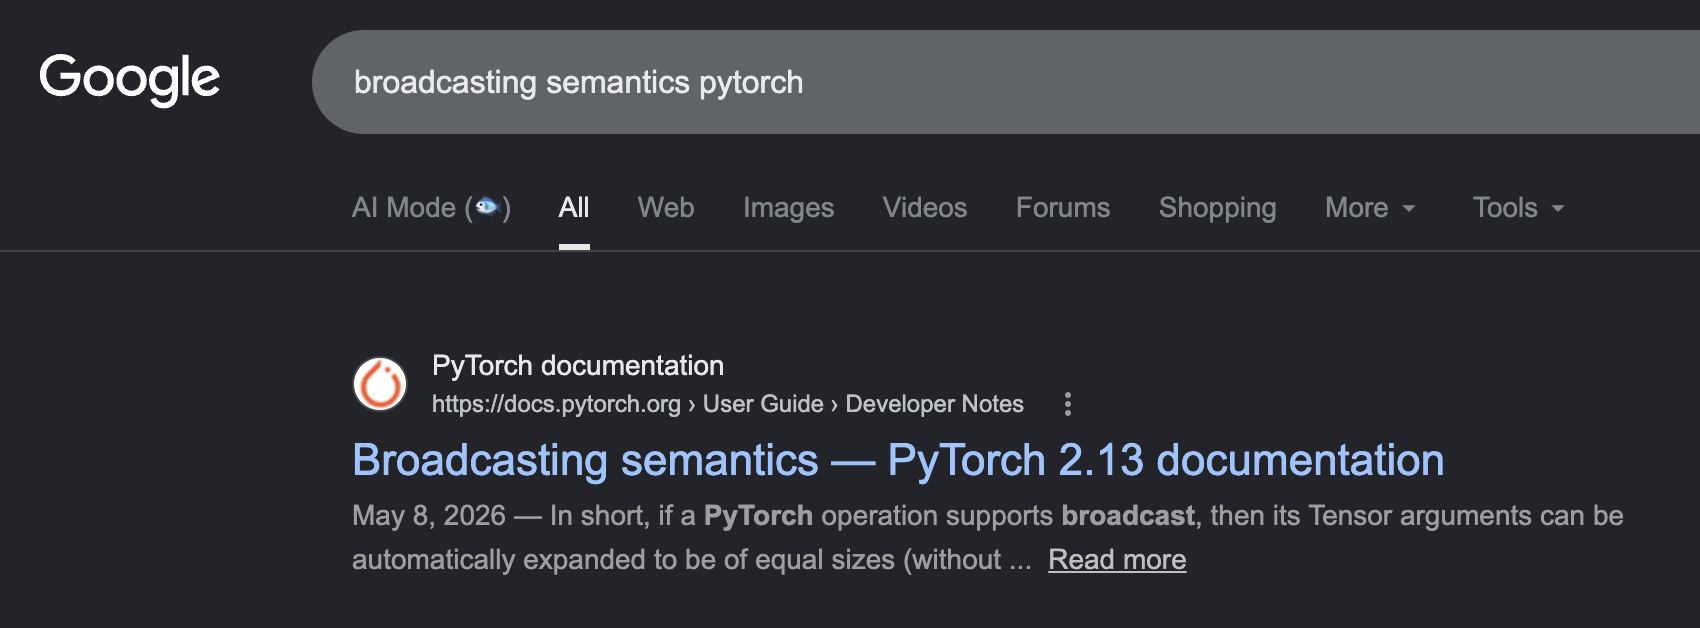

Look at this https://docs.pytorch.org/docs/2.13/notes/broadcasting.html#general-semantics  

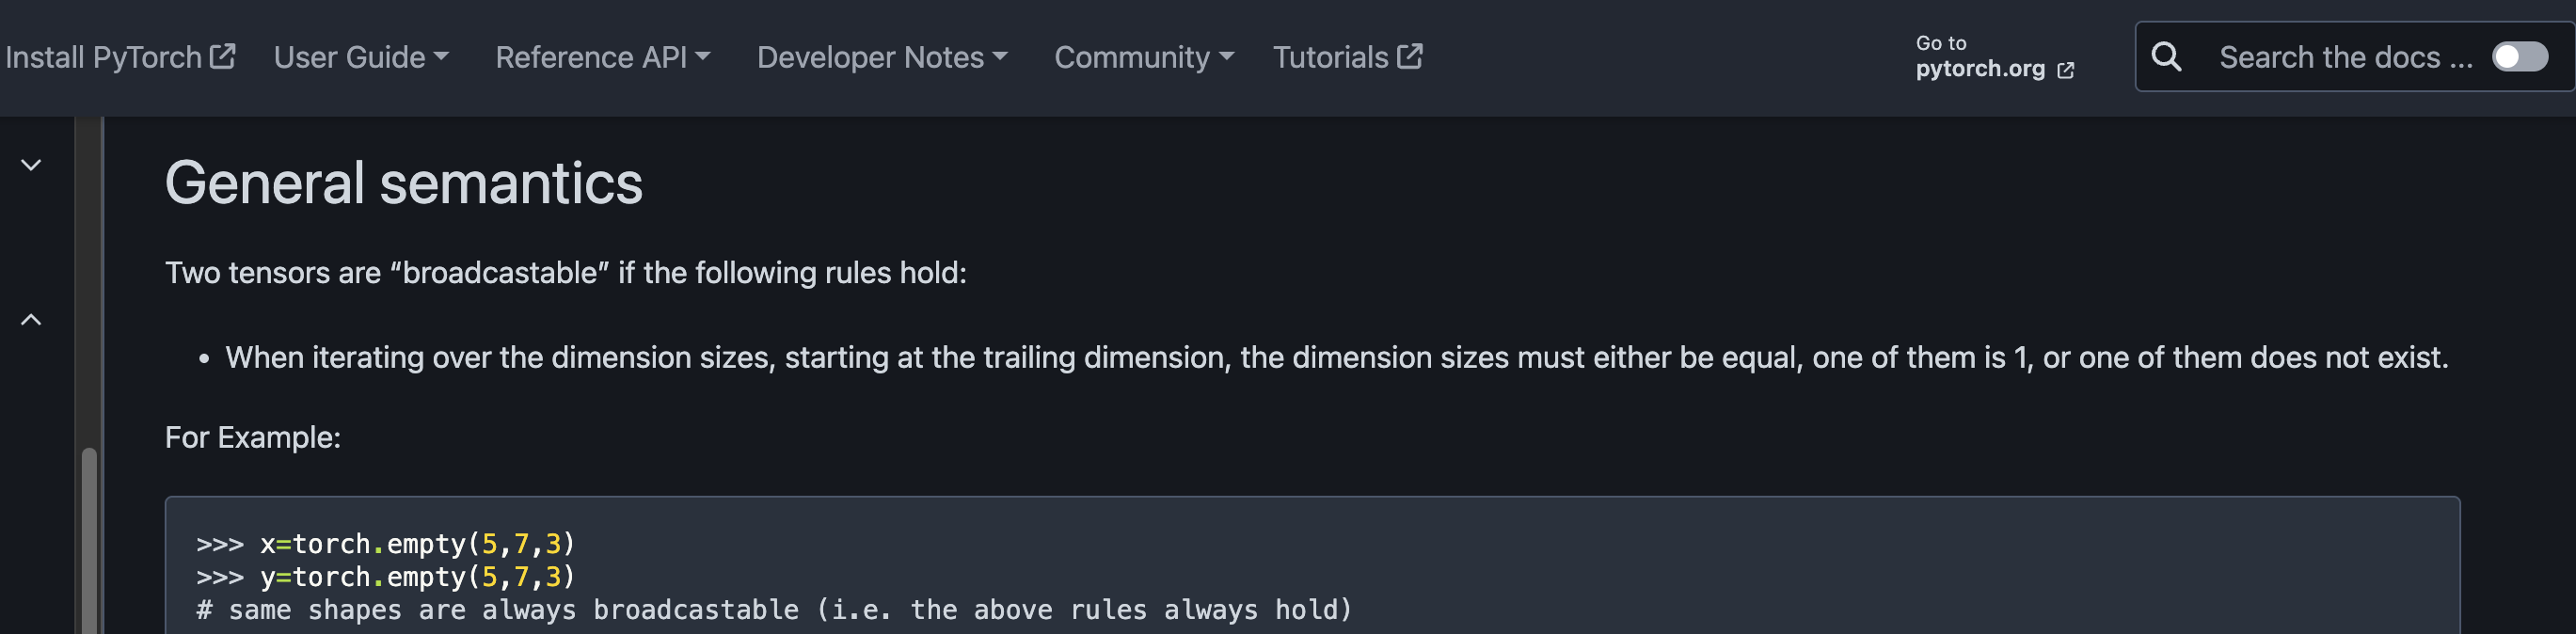

which suggests, we can devide
* 27, 27
* 27, 1

Start looking from trailing (right to left)

what it does is, 
it takes
27, 1 column and copy that 27 times and make it 27, 27 and then devide P by this sum.

## keepdims

* improving efficiency and practice N dimensional tensors (broadcasting)
* Tensor manipulation skill is helpful to build transformer

## Broadcasting is very important, and we can easily run into bugs.
## Andrej specifically stressed to respect it.
* see https://youtu.be/PaCmpygFfXo?si=Y-CszpRkEAjupf2N&t=2660 

In [63]:
P = N.float()
P = P / P.sum(1, keepdims = True) # will normalize every single row
P

tensor([[0.0000e+00, 1.3767e-01, 4.0770e-02, 4.8138e-02, 5.2758e-02, 4.7794e-02,
         1.3018e-02, 2.0885e-02, 2.7284e-02, 1.8450e-02, 7.5610e-02, 9.2498e-02,
         4.9074e-02, 7.9231e-02, 3.5776e-02, 1.2300e-02, 1.6077e-02, 2.8720e-03,
         5.1166e-02, 6.4153e-02, 4.0833e-02, 2.4350e-03, 1.1738e-02, 9.5839e-03,
         4.1832e-03, 1.6702e-02, 2.9001e-02],
        [1.9596e-01, 1.6408e-02, 1.5966e-02, 1.3870e-02, 3.0751e-02, 2.0422e-02,
         3.9546e-03, 4.9579e-03, 6.8821e-02, 4.8694e-02, 5.1645e-03, 1.6763e-02,
         7.4605e-02, 4.8222e-02, 1.6048e-01, 1.8592e-03, 2.4199e-03, 1.7707e-03,
         9.6326e-02, 3.2994e-02, 2.0274e-02, 1.1244e-02, 2.4613e-02, 4.7514e-03,
         5.3711e-03, 6.0499e-02, 1.2838e-02],
        [4.3100e-02, 1.2136e-01, 1.4367e-02, 3.7807e-04, 2.4575e-02, 2.4764e-01,
         0.0000e+00, 0.0000e+00, 1.5501e-02, 8.2042e-02, 3.7807e-04, 0.0000e+00,
         3.8941e-02, 0.0000e+00, 1.5123e-03, 3.9698e-02, 0.0000e+00, 0.0000e+00,
         3.1834e-

In [70]:
P = N.float()
# One more efficiency, inplace operation
# Instead of 
"""
P = P / P.sum(1, keepdims = True) # will normalize every single row
"""
# This is same as above
P /= P.sum(1, keepdims = True) # will normalize every single row


In [71]:
P[0].sum(0) # will be 1 because it is now normalized

tensor(1.)

## Putting all together

In [75]:
g = torch.Generator().manual_seed(912345678) 

for i in range(10):
    out = []
    indexX = 0
    while True:
        p = P[indexX]
        indexX = torch.multinomial(p, num_samples = 1, replacement = True, generator = g).item()
        out.append(itos[indexX])
        if indexX == 0:
            break
    print(''.join(out))

ja.
rik.
s.
a.
xusayremovianeleshay.
jol.
marynga.
ze.
ialetynyn.
gleelin.


Essentially, elements of P above are paramteres of the model

We want to summarize quality of the model. Basically Loss, or training loss in a single number.

In [76]:
for w in words[:3]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        print(f'{ch1}{ch2}: {prob:.4f}')

.e: 0.0478
em: 0.0377
mm: 0.0253
ma: 0.3899
a.: 0.1960
.o: 0.0123
ol: 0.0780
li: 0.1777
iv: 0.0152
vi: 0.3541
ia: 0.1381
a.: 0.1960
.a: 0.1377
av: 0.0246
va: 0.2495
a.: 0.1960


---

We have 27 characters or tokens
So, we have

In [81]:
1/27.0 * 100

3.7037037037037033

is basically 4 percent with equal probability. Meaning every bigram is 4%, so if we end up sampling from this, we would get 4% (or 0.04) probability for all bigrams. But we don't have uniform distribution, like for e..g "a." is 20%, "vi" is 35% probable. Meaning we learned something from our dataset.

So, we should have some mechanism to tell how good our model is, but defining a single function. or a single number: which is loss, that measures quality of model.

Liklihood: is product of all probabilities. Should be as high as possible.
Remember, for micrograd, we had mean squared error.

Since product of all probabilities is a tiny number. So people work with log liklihood. It is basically convenience thing.

https://www.wolframalpha.com/input?i=log%28x%29+from+0+to+1 
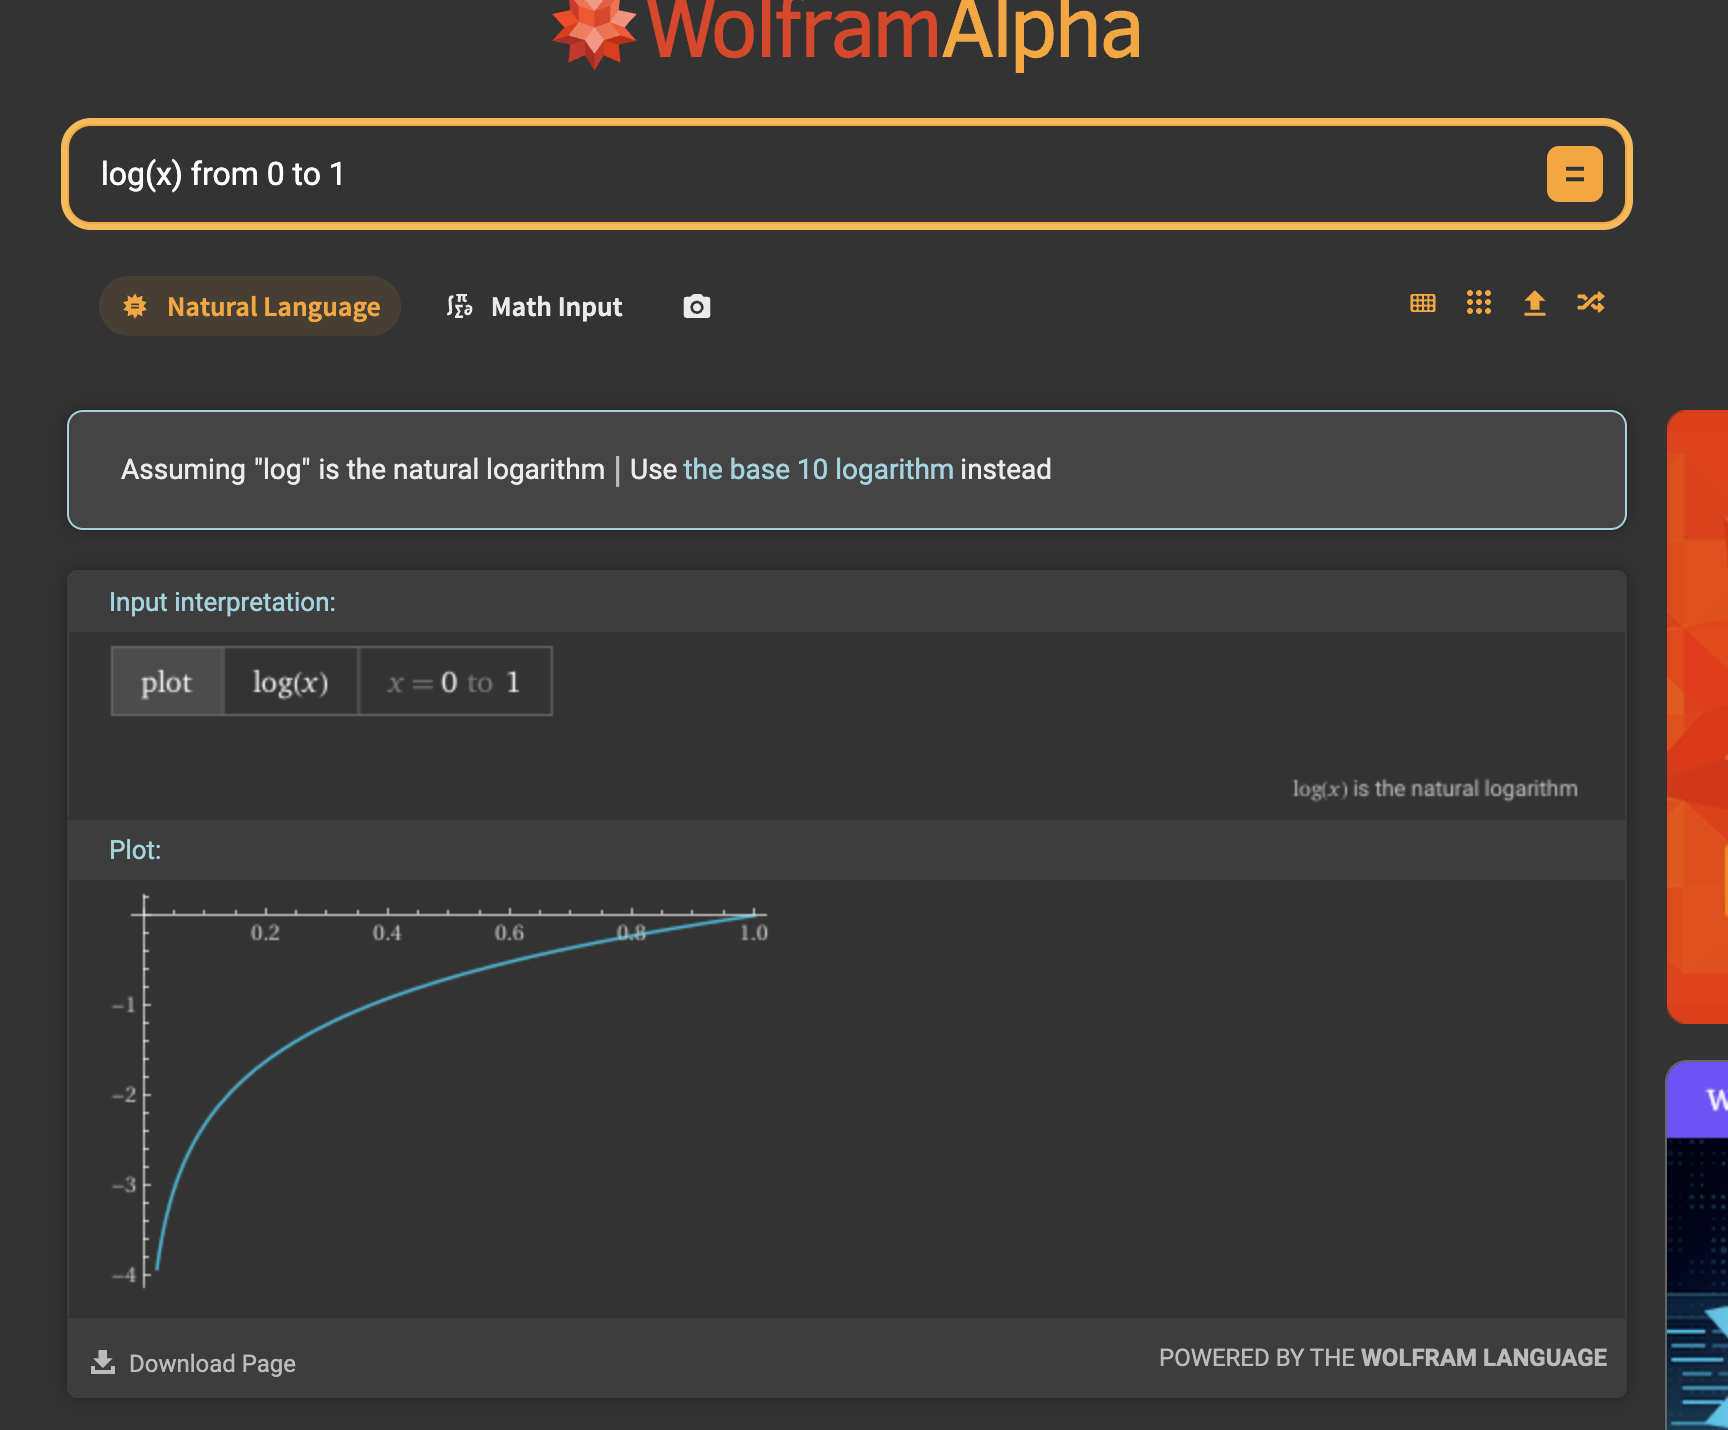

As we can see, log(x) ranges from -inf to 1. Meaning, 
* x tends to 0, log(x) tends to -inf
* x tends to 1, log(x) tends to 1

In [83]:
# So updating our logprob now

for w in words[:3]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

.e: 0.0478 -3.0408
em: 0.0377 -3.2793
mm: 0.0253 -3.6772
ma: 0.3899 -0.9418
a.: 0.1960 -1.6299
.o: 0.0123 -4.3982
ol: 0.0780 -2.5508
li: 0.1777 -1.7278
iv: 0.0152 -4.1867
vi: 0.3541 -1.0383
ia: 0.1381 -1.9796
a.: 0.1960 -1.6299
.a: 0.1377 -1.9829
av: 0.0246 -3.7045
va: 0.2495 -1.3882
a.: 0.1960 -1.6299


In [90]:
# Now that we know log of individual probabilities, if we want log liklihood, we need multiply all probabilities and then log it.
# log(a*b*c) = log(a) + log(b) + log(c)

log_likelihood = 0.0
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
print(f'{log_likelihood=}')


log_likelihood=tensor(-559891.7500)


In [94]:
# we are seeing that more and more negative.
# we have semantics, where low is good, because we want to minimize the loss (purely convenient thing)
# So, we have negative log liklihood. Basically negative of log_likelihood

# One more thing people like to do is, average negative log likelihood (NLL)

log_likelihood = 0.0
n = 0
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll/n=}')

log_likelihood=tensor(-559891.7500)
nll/n=tensor(2.4541)


---

* GOAL: maximize likelihood of the data w.r.t. model parameters (statistical modeling)
* equivalent to maximizing the log likelihood (because log is monotonic)
* equivalent to minimizing the negative log likelihood
* equivalent to minimizing the average negative log likelihood

* log(a*b*c) = log(a) + log(b) + log(c)

In [100]:
# We can actually look at likelihood of my name
log_likelihood = 0.0
n = 0
# for w in words:
for w in ["channabasava"]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')
print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll/n=}')

.c: 0.0481 -3.0337
ch: 0.1880 -1.6713
ha: 0.2946 -1.2220
an: 0.1605 -1.8296
nn: 0.1040 -2.2634
na: 0.1624 -1.8175
ab: 0.0160 -4.1373
ba: 0.1214 -2.1090
as: 0.0330 -3.4114
sa: 0.1482 -1.9094
av: 0.0246 -3.7045
va: 0.2495 -1.3882
a.: 0.1960 -1.6299
log_likelihood=tensor(-30.1272)
nll/n=tensor(2.3175)


So, my name is 2.3 (less than 2.45) meaning it is more likeli for model trained on this dataset.

Now, lets add 'z' in my name, like "channabzasava"



In [101]:
# We can actually look at likelihood of my name
log_likelihood = 0.0
n = 0
# for w in words:
for w in ["channabzasava"]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')
print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll/n=}')

.c: 0.0481 -3.0337
ch: 0.1880 -1.6713
ha: 0.2946 -1.2220
an: 0.1605 -1.8296
nn: 0.1040 -2.2634
na: 0.1624 -1.8175
ab: 0.0160 -4.1373
bz: 0.0000 -inf
za: 0.3586 -1.0255
as: 0.0330 -3.4114
sa: 0.1482 -1.9094
av: 0.0246 -3.7045
va: 0.2495 -1.3882
a.: 0.1960 -1.6299
log_likelihood=tensor(-inf)
nll/n=tensor(inf)


So, we get inf, meaning this is unlikely that channabzasava will be generated.
Because "bz" occurs 0 times in our dataset.

So, there is a solution to this. It is called "Model smoothening". Like adding 1 to everything

In [105]:
# adding 1 to all counters
P = (N + 1).float()
P /= P.sum(1, keepdims = True) # will normalize every single row

# We can actually look at likelihood of my name
log_likelihood = 0.0
n = 0
# for w in words:
for w in ["channabzasava"]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')
print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll/n=}')

.c: 0.0481 -3.0339
ch: 0.1869 -1.6774
ha: 0.2937 -1.2251
an: 0.1604 -1.8302
nn: 0.1039 -2.2643
na: 0.1623 -1.8186
ab: 0.0160 -4.1363
bz: 0.0004 -7.8906
za: 0.3551 -1.0355
as: 0.0330 -3.4113
sa: 0.1478 -1.9119
av: 0.0246 -3.7041
va: 0.2473 -1.3971
a.: 0.1958 -1.6305
log_likelihood=tensor(-36.9668)
nll/n=tensor(2.6405)


In [106]:
# instead of adding 1, we can add a larger number, which will actually smoothen out the model
# essentially, it will tend towards normal distribution.


# adding 1000000 to all counters
P = (N + 1000000).float()
P /= P.sum(1, keepdims = True) # will normalize every single row

# We can actually look at likelihood of my name
log_likelihood = 0.0
n = 0
# for w in words:
for w in ["channabzasava"]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')
print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll/n=}')

.c: 0.0371 -3.2955
ch: 0.0371 -3.2953
ha: 0.0371 -3.2939
an: 0.0372 -3.2917
nn: 0.0371 -3.2946
na: 0.0371 -3.2935
ab: 0.0370 -3.2966
bz: 0.0370 -3.2959
za: 0.0371 -3.2951
as: 0.0370 -3.2960
sa: 0.0371 -3.2949
av: 0.0370 -3.2963
va: 0.0371 -3.2953
a.: 0.0372 -3.2905
log_likelihood=tensor(-46.1250)
nll/n=tensor(3.2946)


# Summary

We trained a respectable bigram character-level language model. And we saw that we both trained the model by looking at the counts of all the bigrams and normalizing the rows to get probability distributions. We saw that we can also then use those parameters of this model

* to perform sampling of new words. So we sample new names according to those distributions.
* And we also saw that we can evaluate the quality of this model.

The quality of this model is summarized in a single number, which is the negative log likelihood. 
The lower this number is, the better the model is because it is giving high probabilities to the actual next characters in all the bigrams in our training set. 

We've arrived at this model explicitly by doing something that felt sensible. We were just performing counts and then we were normalizing those counts.